## Drop Columns that not helpful for Categorization Model

In [7]:
import pandas as pd

email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Category Modeling/final_email_category_balanced.csv')

In [ ]:
email_data

In [2]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242379 entries, 0 to 242378
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   From              242379 non-null  object
 1   To                235681 non-null  object
 2   Subject           235589 non-null  object
 3   Message           242378 non-null  object
 4   Day               242379 non-null  object
 5   Date & Time       242379 non-null  object
 6   url_count         242379 non-null  int64 
 7   Cleaned_Subject   227561 non-null  object
 8   Cleaned_Message   241774 non-null  object
 9   Combined_Text     242379 non-null  object
 10  Qwen2.5_Category  242379 non-null  object
dtypes: int64(1), object(10)
memory usage: 20.3+ MB


In [3]:
email_data = email_data.drop(columns=['From', 'To', 'Day', 'Date & Time', 'Subject', 'Day', 'Date & Time'])

In [4]:
email_data = email_data.drop(columns=['Message', 'url_count'])
#Cleaned_Subject', 'Combined_Text'

In [5]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242379 entries, 0 to 242378
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Cleaned_Subject   227561 non-null  object
 1   Cleaned_Message   241774 non-null  object
 2   Combined_Text     242379 non-null  object
 3   Qwen2.5_Category  242379 non-null  object
dtypes: object(4)
memory usage: 7.4+ MB


In [14]:
email_data['Qwen2.5_Category'].value_counts()

Qwen2.5_Category
General Business Communication              55924
Finance & Transactions                      35682
Personal Communication & Purely Personal    29053
Meeting & Scheduling                        21720
IT Alerts & System Notifications            20000
Spam                                        20000
Legal & Contractual                         20000
Project Management & Strategy               20000
Internal Policies & HR Updates              20000
Name: count, dtype: int64

## Model Building - Linear Regression

#(1) TfidfVectorizer - Unigram - Linear Regression - Cleaned_Message | Acc: 76%

Column: Cleaned_Message
LR: 1U - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.67      0.66      0.66      7136
          General Business Communication       0.69      0.55      0.61     11185
        IT Alerts & System Notifications       0.93      0.92      0.92      4000
          Internal Policies & HR Updates       0.98      0.93      0.96      4000
                     Legal & Contractual       0.62      0.78      0.69      4000
                    Meeting & Scheduling       0.71      0.80      0.75      4344
Personal Communication & Purely Personal       0.66      0.83      0.74      5811
           Project Management & Strategy       0.92      0.85      0.88      4000
                                    Spam       0.95      0.92      0.93      4000

                                accuracy                           0.76     48476
                             

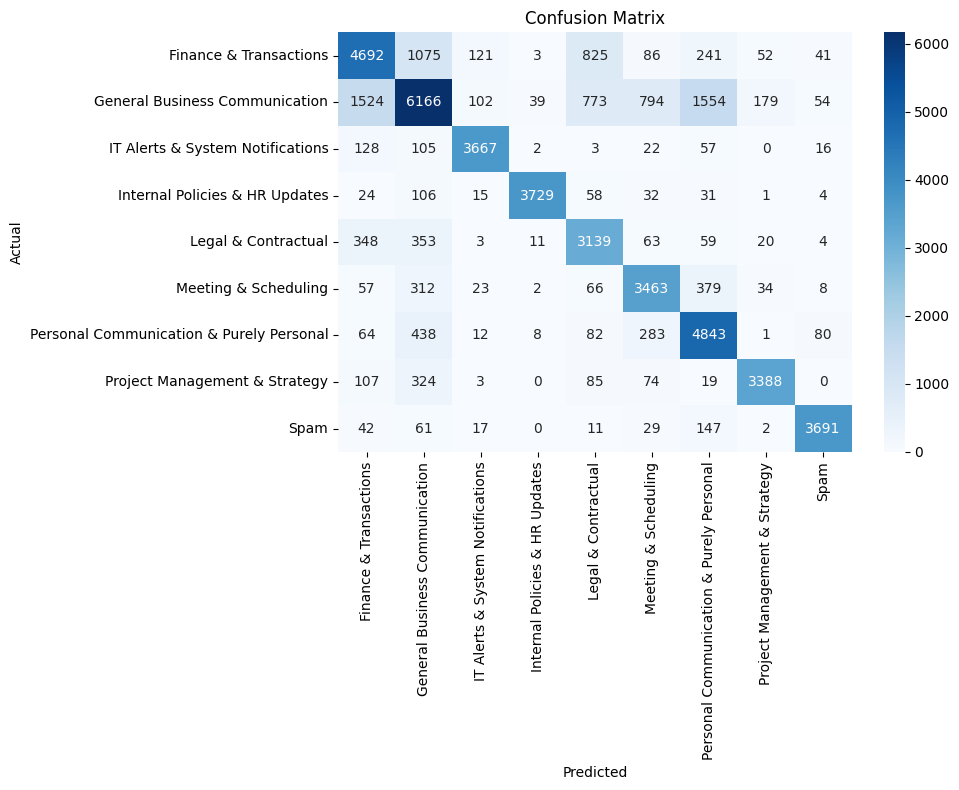

✅ Model saved successfully.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 1U - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_u_5000_lr_model.pkl')

print("✅ Model saved successfully.")

#(2) TfidfVectorizer - Bigram - Linear Regression - Cleaned_Message | Acc: 59%

Column: Cleaned_Message
LR: 2B - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.62      0.33      0.43      7136
          General Business Communication       0.49      0.25      0.33     11185
        IT Alerts & System Notifications       0.97      0.88      0.92      4000
          Internal Policies & HR Updates       1.00      0.92      0.96      4000
                     Legal & Contractual       0.56      0.59      0.58      4000
                    Meeting & Scheduling       0.66      0.55      0.60      4344
Personal Communication & Purely Personal       0.28      0.81      0.41      5811
           Project Management & Strategy       1.00      0.80      0.89      4000
                                    Spam       0.96      0.86      0.91      4000

                                accuracy                           0.59     48476
                             

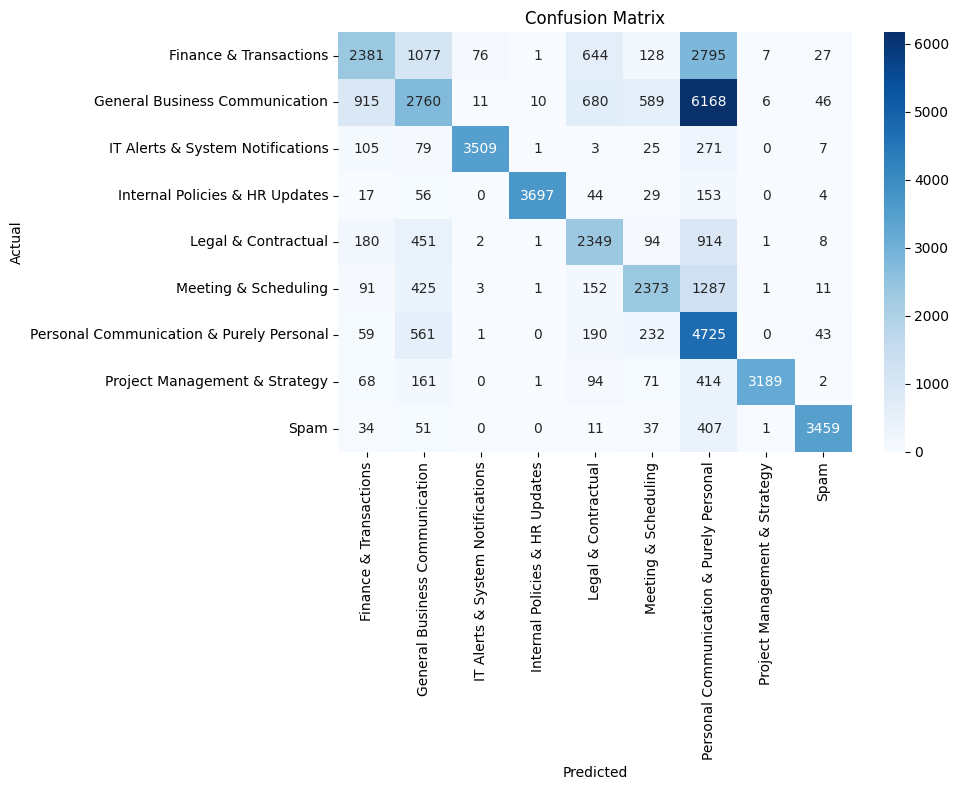

✅ Model saved successfully.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 2B - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_b_5000_lr_model.pkl')

print("✅ Model saved successfully.")

#(3) TfidfVectorizer - Uni,Bigram - Linear Regression - Cleaned_Message | Acc: 75%

Column: Cleaned_Message
LR: 1U,2B - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.67      0.65      0.66      7136
          General Business Communication       0.68      0.55      0.60     11185
        IT Alerts & System Notifications       0.94      0.91      0.92      4000
          Internal Policies & HR Updates       0.98      0.93      0.96      4000
                     Legal & Contractual       0.61      0.78      0.69      4000
                    Meeting & Scheduling       0.71      0.79      0.74      4344
Personal Communication & Purely Personal       0.65      0.83      0.73      5811
           Project Management & Strategy       0.92      0.84      0.88      4000
                                    Spam       0.95      0.92      0.93      4000

                                accuracy                           0.75     48476
                          

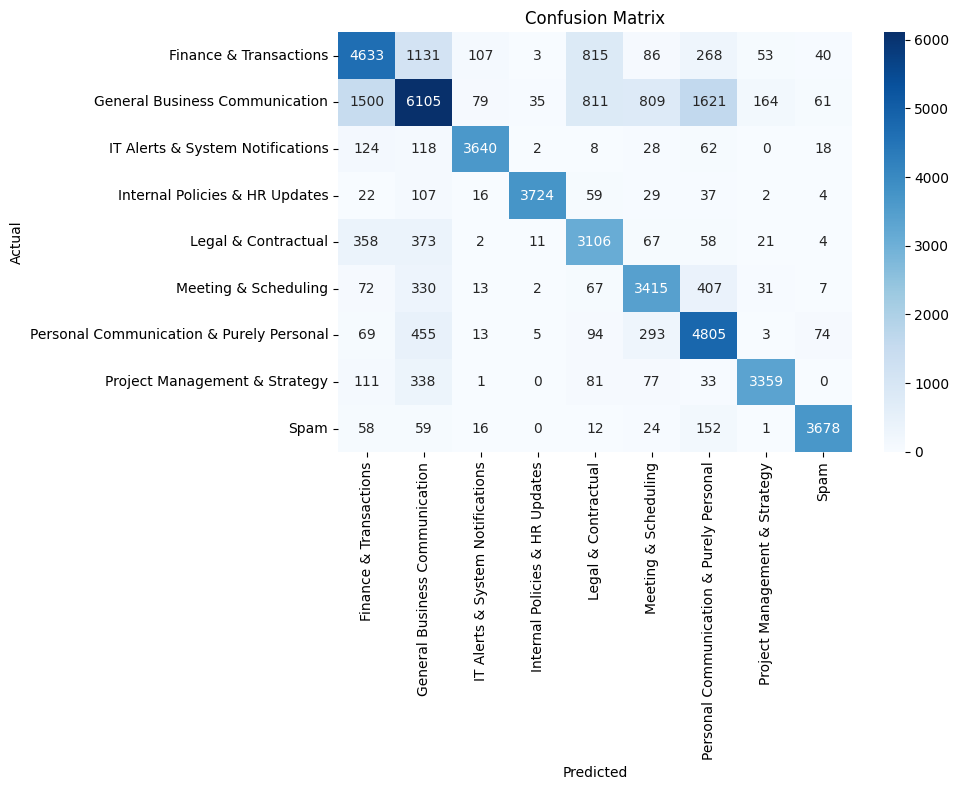

✅ Model saved successfully.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 1U,2B - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_ub_5000_lr_model.pkl')

print("✅ Model saved successfully.")

Default Regression Model Conclusion - 5000 features (1,2)

*High Accuracy*
1) Spam - F1-Score = 0.93
2) IT Alerts & System Notifications - F1-Score = 0.92
3) Internal Policies & HR Updates - F1-Score = 0.96
4) Project Management & Strategy - F1-Score = 0.88

*Confused or Moderate Categories*
1) General Business Communication - F1-Score = 0.61 - Most confused category (Finance, Personal, Meeting)
2) Finance & Transactions - F1-Score = 0.66 - Heavy overlap in transactional phrasing (Business,Legal) 	
3) Personal Communication - F1-Score = 0.72	- Overlap in informal tone (Business, Meeting)
4) Legal & Contractual - F1-Score = 0.69 - Needs stronger phrase detection (0.69)

*Misclassification*

a. General Business Communication misclassified (Finance 1566), (Personal 1507), (Meeting 844), (Legal 773)

b. Legal & Contractual overlaps (Finance 334), (Business 384)

c. Finance & Transactions misclassified (Business 1126, Legal 803)

#(4) TfidfVectorizer - Uni,Bi,Trigram - Linear Regression - Cleaned_Message - Acc: 75%

Column: Cleaned_Message
LR: 1,3 UBT - Max:8000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.66      0.64      0.65      7136
          General Business Communication       0.67      0.53      0.59     11185
        IT Alerts & System Notifications       0.94      0.90      0.92      4000
          Internal Policies & HR Updates       0.99      0.93      0.96      4000
                     Legal & Contractual       0.61      0.77      0.68      4000
                    Meeting & Scheduling       0.70      0.78      0.74      4344
Personal Communication & Purely Personal       0.63      0.82      0.71      5811
           Project Management & Strategy       0.93      0.84      0.88      4000
                                    Spam       0.94      0.92      0.93      4000

                                accuracy                           0.75     48476
                        

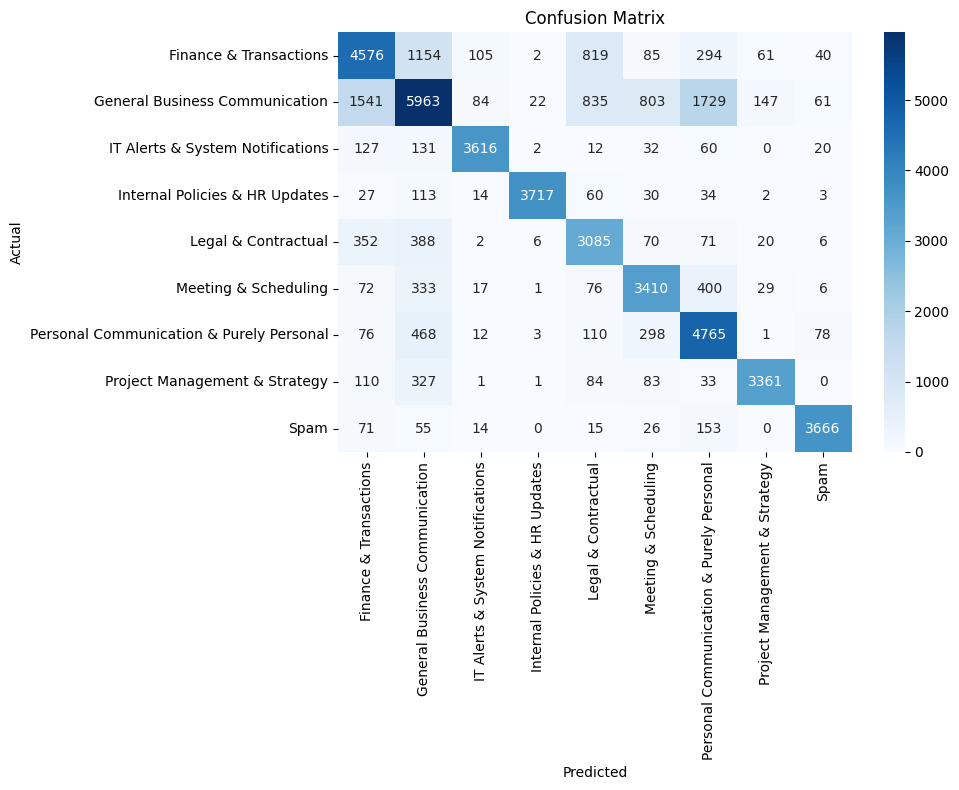

✅ Model saved successfully.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 1,3 UBT - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_ubt_8000_lr_model.pkl')

print("✅ Model saved successfully.")

---------------------------------------------------------------------------------

## Model Building - Random Forest

#(1) TfidfVectorizer - Unigram - Random Forest - Cleaned_Message - Acc: %

Column: Cleaned_Message
RF: 1,1 U - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.74      0.62      0.67      7130
          General Business Communication       0.61      0.74      0.67     11157
        IT Alerts & System Notifications       0.96      0.92      0.94      4000
          Internal Policies & HR Updates       0.99      0.94      0.96      4000
                     Legal & Contractual       0.73      0.71      0.72      4000
                    Meeting & Scheduling       0.76      0.76      0.76      4342
Personal Communication & Purely Personal       0.73      0.73      0.73      5738
           Project Management & Strategy       0.96      0.83      0.89      4000
                                    Spam       0.97      0.93      0.95      3988

                                accuracy                           0.77     48355
                          

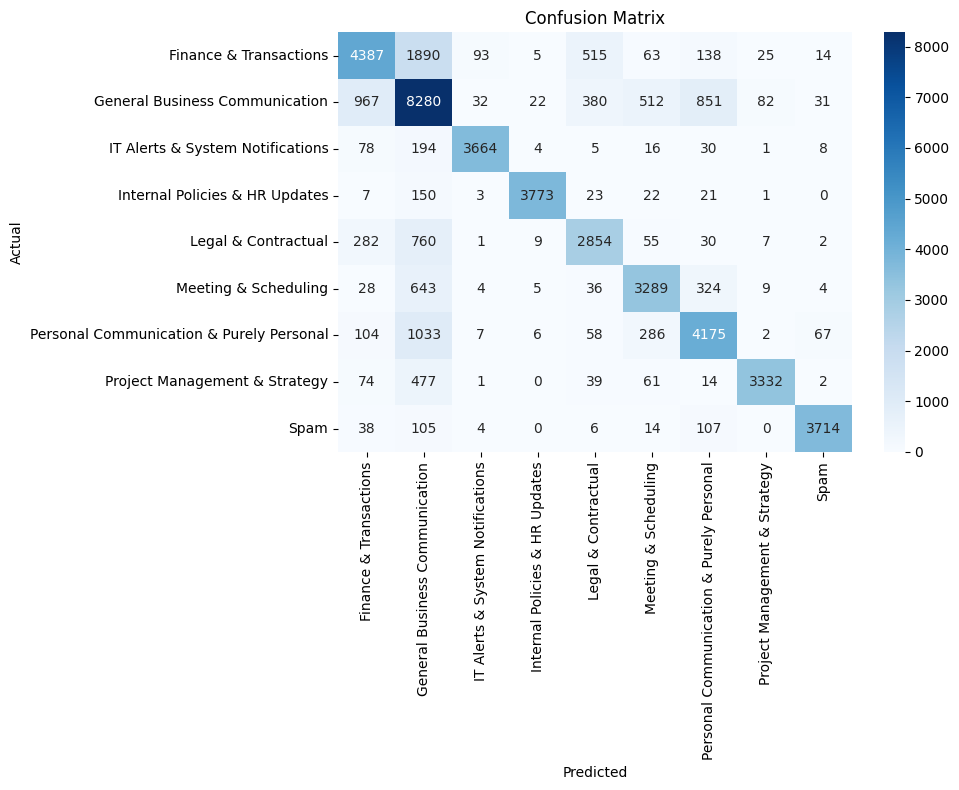

✅ Model saved successfully.


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"RF: 1,1 U - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_u_5000_rf_model.pkl')

print("✅ Model saved successfully.")

#(2) TfidfVectorizer - Bigram - Random Forest - Cleaned_Message - Acc: ??%

#(3) TfidfVectorizer - Uni,Bigram - Random Forest - Cleaned_Message - Acc: 77%

Column: Cleaned_Message
RF: 1,2 UBT - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.73      0.62      0.67      7130
          General Business Communication       0.61      0.74      0.67     11157
        IT Alerts & System Notifications       0.96      0.91      0.94      4000
          Internal Policies & HR Updates       0.99      0.94      0.96      4000
                     Legal & Contractual       0.73      0.71      0.72      4000
                    Meeting & Scheduling       0.77      0.75      0.76      4342
Personal Communication & Purely Personal       0.73      0.73      0.73      5738
           Project Management & Strategy       0.96      0.83      0.89      4000
                                    Spam       0.97      0.93      0.95      3988

                                accuracy                           0.77     48355
                        

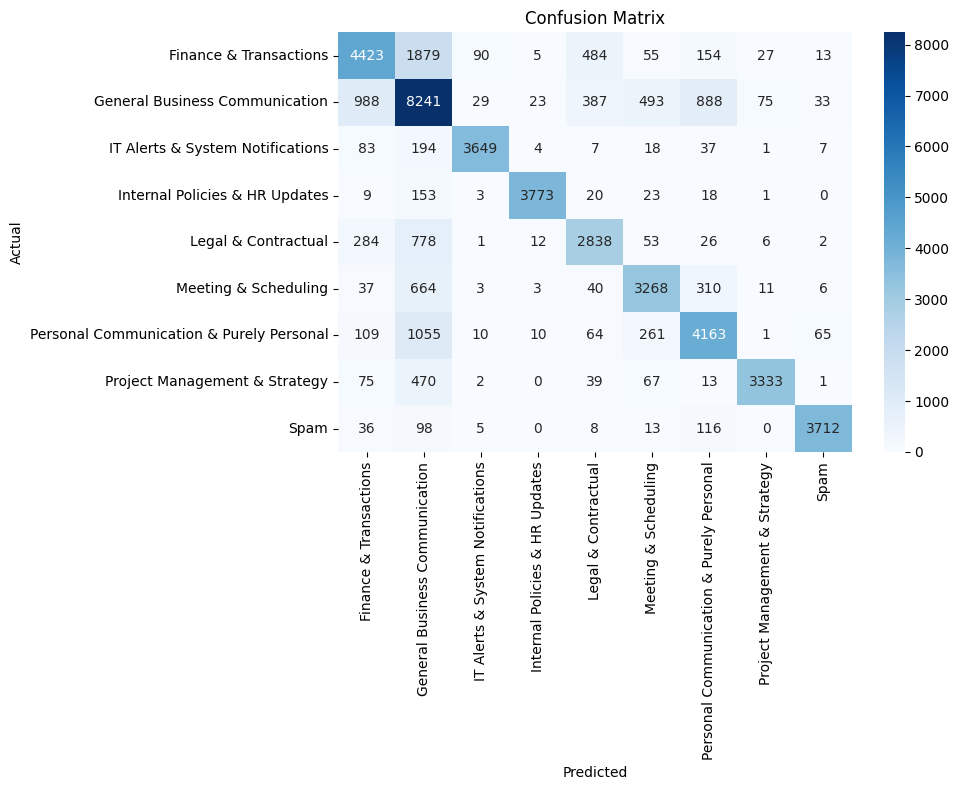

✅ Model saved successfully.


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"RF: 1,2 UBT - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_ub_5000_rf_model.pkl')

print("✅ Model saved successfully.")

#(4) TfidfVectorizer - Uni,Bi, Trigram - Random Forest - Cleaned_Message - Acc: ???%

## Model Building - SVM

#(3) TfidfVectorizer - Uni,Bigram - SVM - Cleaned_Message - Acc: 75%

Column: Cleaned_Message
SVM: 1,2 UB - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.67      0.64      0.65      7130
          General Business Communication       0.66      0.58      0.62     11157
        IT Alerts & System Notifications       0.94      0.91      0.92      4000
          Internal Policies & HR Updates       0.99      0.93      0.96      4000
                     Legal & Contractual       0.64      0.77      0.70      4000
                    Meeting & Scheduling       0.70      0.78      0.74      4342
Personal Communication & Purely Personal       0.66      0.80      0.72      5738
           Project Management & Strategy       0.96      0.82      0.89      4000
                                    Spam       0.93      0.92      0.93      3988

                                accuracy                           0.75     48355
                        

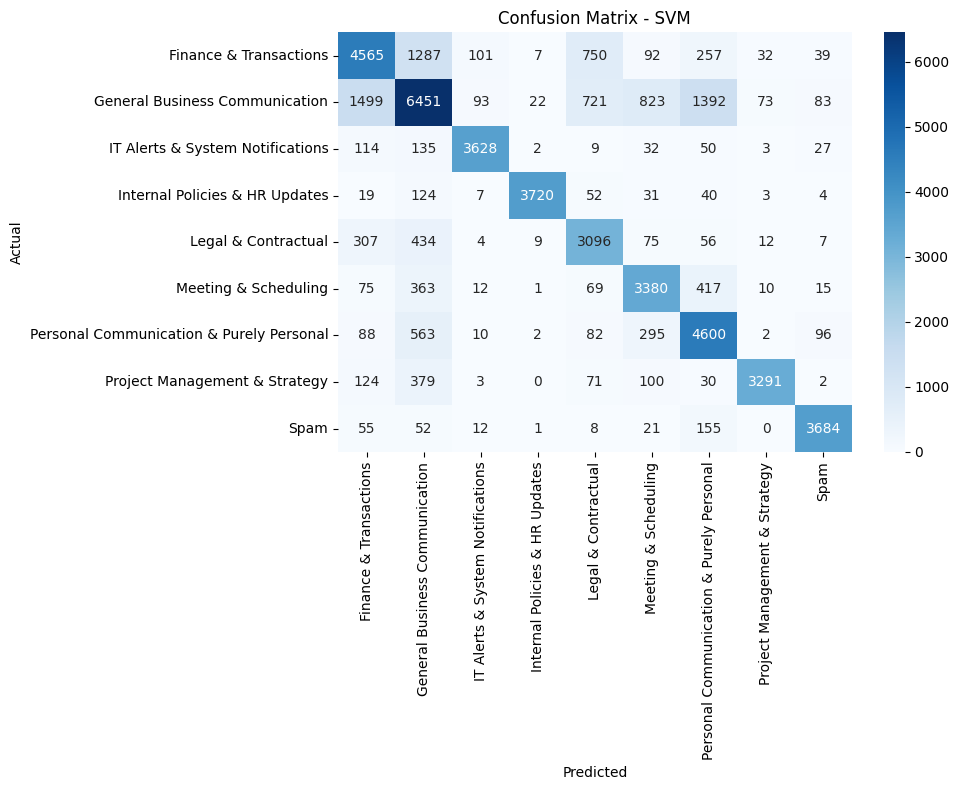

✅ Model saved successfully.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train SVM classifier
model = LinearSVC(class_weight='balanced', max_iter=2000)
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"SVM: 1,2 UB - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_ub_5000_svm_model.pkl')

print("✅ Model saved successfully.")

#(4) TfidfVectorizer - Uni,Bi, Trigram - SVM - Cleaned_Message - Acc: ???%

Column: Cleaned_Message
SVM: 1,3 UBT - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.66      0.63      0.65      7130
          General Business Communication       0.65      0.57      0.61     11157
        IT Alerts & System Notifications       0.94      0.91      0.92      4000
          Internal Policies & HR Updates       0.99      0.93      0.96      4000
                     Legal & Contractual       0.63      0.76      0.69      4000
                    Meeting & Scheduling       0.69      0.78      0.73      4342
Personal Communication & Purely Personal       0.64      0.80      0.71      5738
           Project Management & Strategy       0.96      0.82      0.89      4000
                                    Spam       0.93      0.93      0.93      3988

                                accuracy                           0.75     48355
                       

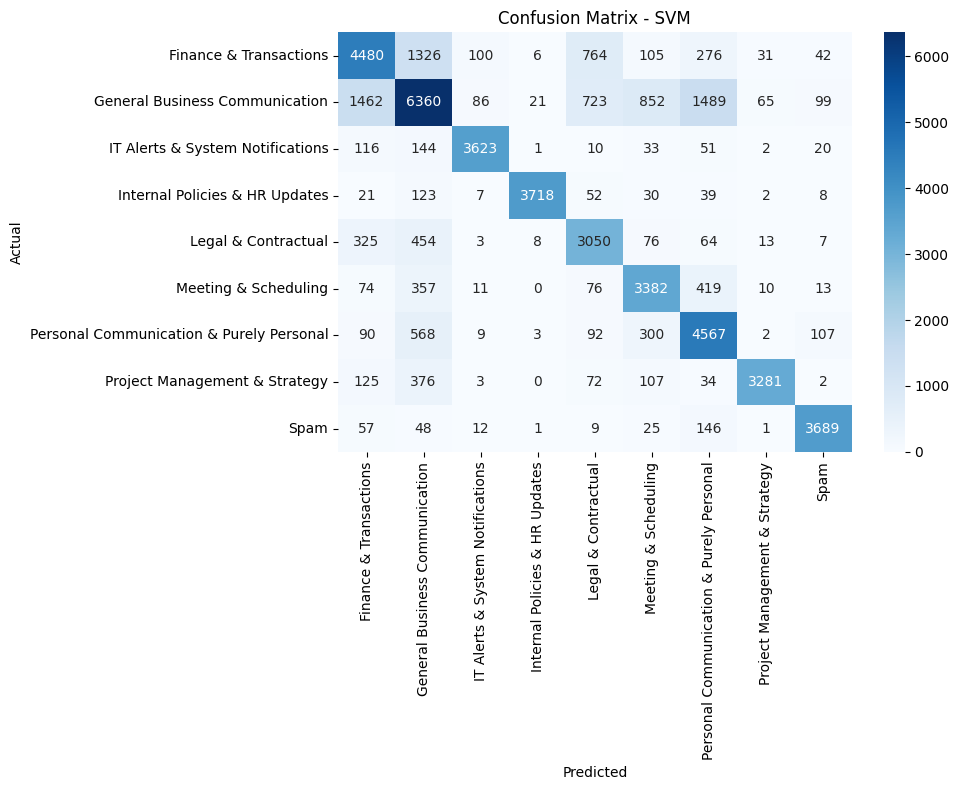

✅ Model saved successfully.


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train SVM classifier
model = LinearSVC(class_weight='balanced', max_iter=2000)
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"SVM: 1,3 UBT - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_ubt_5000_svm_model.pkl')

print("✅ Model saved successfully.")

## Model Building - Naive Bayes

#(1) TfidfVectorizer - Unigram - NB - Cleaned_Message - Acc: 70%

Column: Cleaned_Message
NB: 1,1 U - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.73      0.44      0.55      7130
          General Business Communication       0.48      0.85      0.61     11157
        IT Alerts & System Notifications       0.98      0.86      0.92      4000
          Internal Policies & HR Updates       1.00      0.92      0.96      4000
                     Legal & Contractual       0.68      0.51      0.58      4000
                    Meeting & Scheduling       0.86      0.49      0.63      4342
Personal Communication & Purely Personal       0.75      0.63      0.69      5738
           Project Management & Strategy       1.00      0.80      0.89      4000
                                    Spam       0.99      0.84      0.91      3988

                                accuracy                           0.70     48355
                          

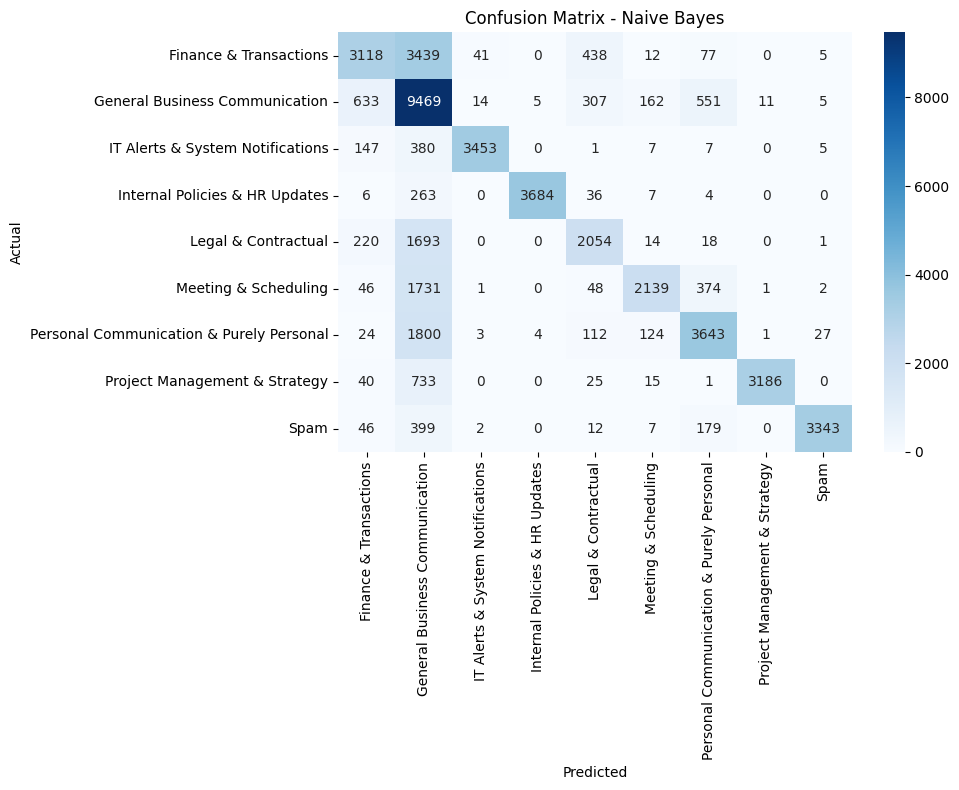

✅ Model saved successfully.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 1,1 U - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_u_5000_nb_model.pkl')

print("✅ Model saved successfully.")

#(2) TfidfVectorizer - Bigram - NB - Cleaned_Message - Acc: 62%

Column: Cleaned_Message
NB: 2,2 B - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.77      0.21      0.32      7130
          General Business Communication       0.39      0.93      0.55     11157
        IT Alerts & System Notifications       0.99      0.85      0.91      4000
          Internal Policies & HR Updates       1.00      0.92      0.96      4000
                     Legal & Contractual       0.75      0.41      0.53      4000
                    Meeting & Scheduling       0.84      0.37      0.52      4342
Personal Communication & Purely Personal       0.63      0.20      0.30      5738
           Project Management & Strategy       1.00      0.80      0.88      4000
                                    Spam       0.98      0.85      0.91      3988

                                accuracy                           0.62     48355
                          

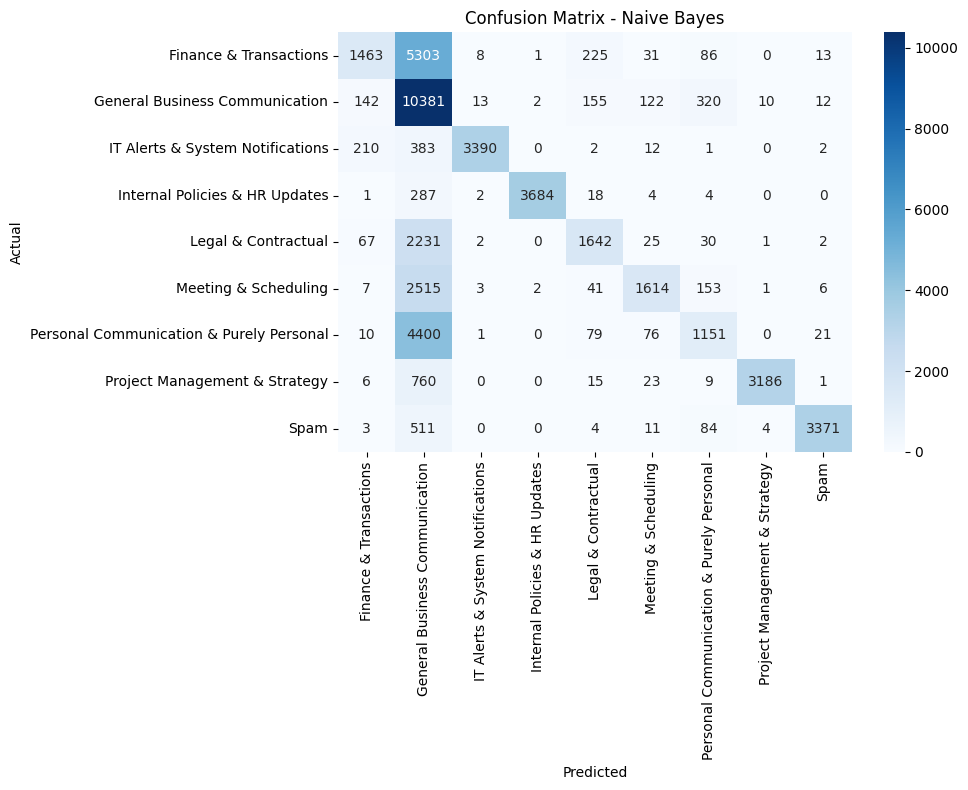

✅ Model saved successfully.


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 2,2 B - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_b_5000_nb_model.pkl')

print("✅ Model saved successfully.")

#(3) TfidfVectorizer - Uni,Bigram - NB - Cleaned_Message - Acc: 69%

Column: Cleaned_Message
NB: 1,2 UB - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.77      0.34      0.47      7130
          General Business Communication       0.45      0.89      0.60     11157
        IT Alerts & System Notifications       1.00      0.84      0.91      4000
          Internal Policies & HR Updates       1.00      0.92      0.96      4000
                     Legal & Contractual       0.70      0.48      0.57      4000
                    Meeting & Scheduling       0.88      0.45      0.59      4342
Personal Communication & Purely Personal       0.75      0.60      0.67      5738
           Project Management & Strategy       1.00      0.80      0.89      4000
                                    Spam       0.99      0.82      0.90      3988

                                accuracy                           0.69     48355
                         

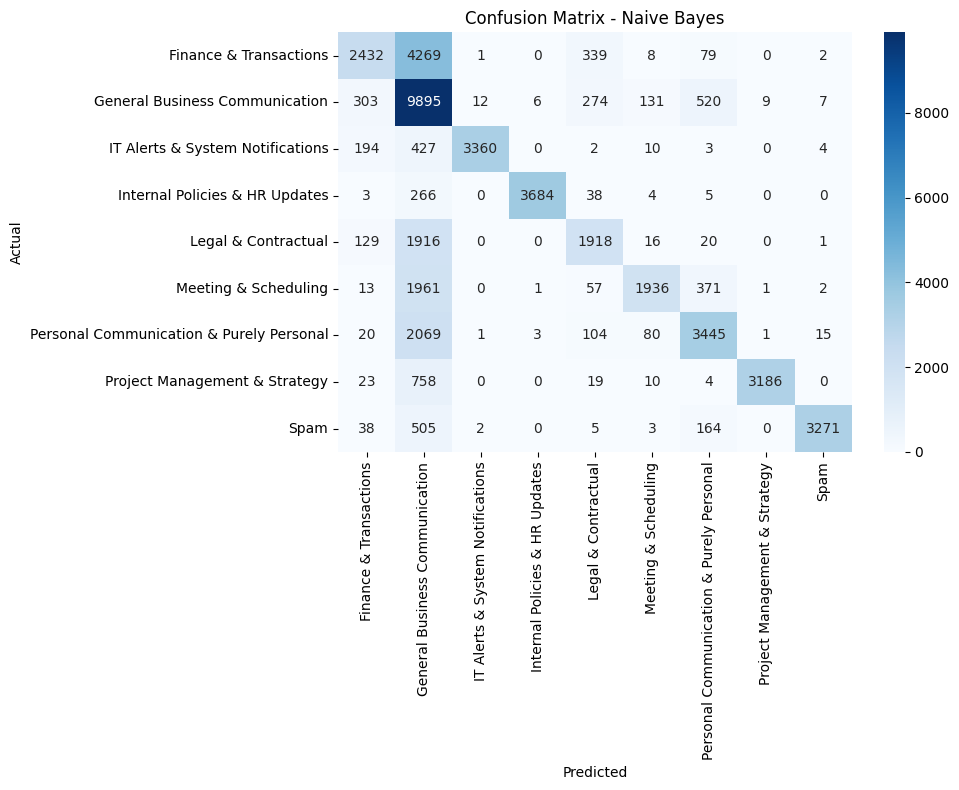

✅ Model saved successfully.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 1,2 UB - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_ub_5000_nb_model.pkl')

print("✅ Model saved successfully.")

#(4) TfidfVectorizer - Uni,Bi, Trigram - NB - Cleaned_Message - Acc: 69%

Column: Cleaned_Message
NB: 1,3 UBT - Max:5000 - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.78      0.29      0.43      7130
          General Business Communication       0.43      0.90      0.58     11157
        IT Alerts & System Notifications       0.99      0.83      0.91      4000
          Internal Policies & HR Updates       1.00      0.92      0.96      4000
                     Legal & Contractual       0.71      0.44      0.54      4000
                    Meeting & Scheduling       0.90      0.41      0.57      4342
Personal Communication & Purely Personal       0.74      0.57      0.65      5738
           Project Management & Strategy       1.00      0.80      0.89      4000
                                    Spam       0.99      0.81      0.89      3988

                                accuracy                           0.67     48355
                        

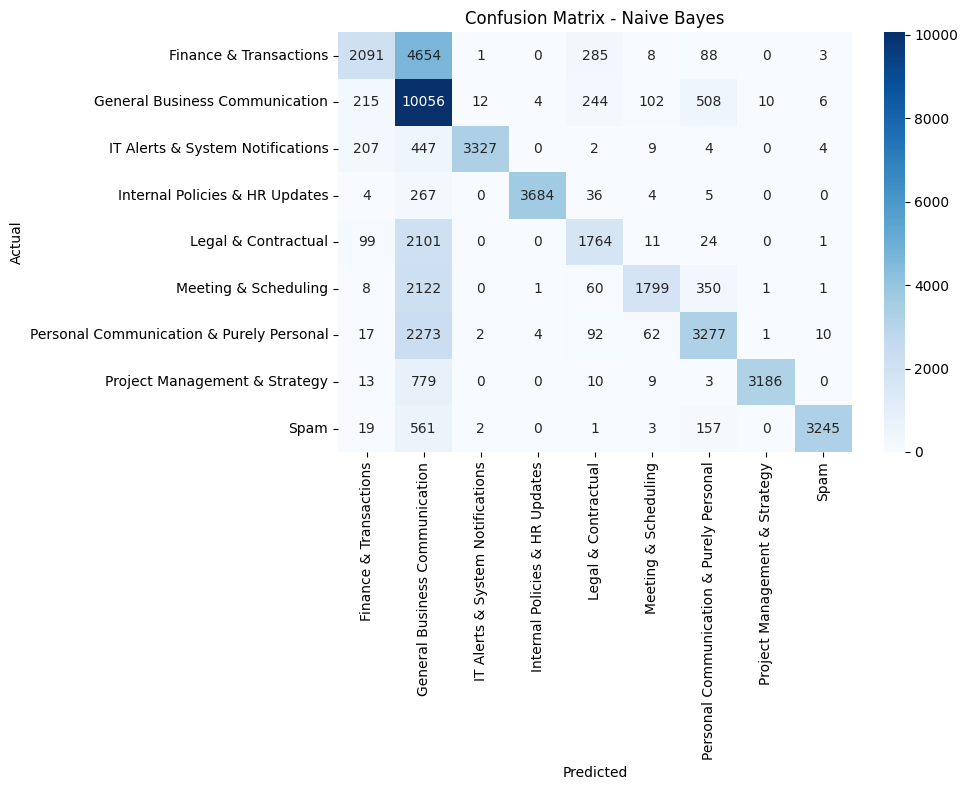

✅ Model saved successfully.


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Cleaned_Message']
y = email_data['Qwen2.5_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 1,3 UBT - Max:{vectorizer.max_features} - Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

import joblib

# Save only the trained logistic regression model
joblib.dump(model, 'email_cm_ubt_5000_nb_model.pkl')

print("✅ Model saved successfully.")

## Model Buidling - Hybrid Model

#(3) TfidfVectorizer - Uni,Bigram - HM - Cleaned_Message - Acc: %

## Other

In [ ]:
#Identifying common phrases for TFIDF
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

label_filter = None

y_label = email_data if label_filter is None else email_data[email_data['Qwen2.5_Category'] == label_filter]

tfidf = TfidfVectorizer(max_features=1500)  
X_tfidf = tfidf.fit_transform(y_label['Cleaned_Message'])

general_xy_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

print("Top TF-IDF Features::\n", general_xy_tfidf_df.sum(axis=0).sort_values(ascending=False))

Top TF-IDF Features::
 new            8368.915767
the            6773.902936
review         4886.102995
is             4858.803745
project        4751.164244
                  ...     
carr            119.915210
ectrt           106.140916
binding         105.343012
enforceable      98.898773
estoppel         94.259354
Length: 1500, dtype: float64
